In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Warehouse_and_Retail_Sales.csv")

In [3]:
print("Shape of Dataset:", df.shape)
print("\nColumns:\n", df.columns)
print("\nFirst 5 Rows:\n", df.head())

print("\nMissing Values:\n", df.isnull().sum())

print("\nData Types:\n", df.dtypes)

print("\nStatistical Summary:\n", df.describe())

Shape of Dataset: (307645, 9)

Columns:
 Index(['YEAR', 'MONTH', 'SUPPLIER', 'ITEM CODE', 'ITEM DESCRIPTION',
       'ITEM TYPE', 'RETAIL SALES', 'RETAIL TRANSFERS', 'WAREHOUSE SALES'],
      dtype='object')

First 5 Rows:
    YEAR  MONTH                           SUPPLIER ITEM CODE  \
0  2020      1  REPUBLIC NATIONAL DISTRIBUTING CO    100009   
1  2020      1                          PWSWN INC    100024   
2  2020      1            RELIABLE CHURCHILL LLLP      1001   
3  2020      1          LANTERNA DISTRIBUTORS INC    100145   
4  2020      1               DIONYSOS IMPORTS INC    100293   

                      ITEM DESCRIPTION ITEM TYPE  RETAIL SALES  \
0                  BOOTLEG RED - 750ML      WINE          0.00   
1            MOMENT DE PLAISIR - 750ML      WINE          0.00   
2  S SMITH ORGANIC PEAR CIDER - 18.7OZ      BEER          0.00   
3        SCHLINK HAUS KABINETT - 750ML      WINE          0.00   
4       SANTORINI GAVALA WHITE - 750ML      WINE          0.82   



In [4]:
df.head()

,YEAR,MONTH,SUPPLIER,ITEM CODE,ITEM DESCRIPTION,ITEM TYPE,RETAIL SALES,RETAIL TRANSFERS,WAREHOUSE SALES
0,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0
1,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0
2,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0
3,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0
4,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0


In [5]:
df["ITEM DESCRIPTION"].unique()

array(['BOOTLEG RED - 750ML', 'MOMENT DE PLAISIR - 750ML',
       'S SMITH ORGANIC PEAR CIDER - 18.7OZ', ...,
       'BENEDIKTINER HELLES LAGER - 50L', 'GULDEN DRAAK TRIPEL 1/2 KEG',
       'ATLAS BULLPEN PILSNER 1/2 KEG'], shape=(34822,), dtype=object)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

YEAR                  0
MONTH                 0
SUPPLIER            167
ITEM CODE             0
ITEM DESCRIPTION      0
ITEM TYPE             1
RETAIL SALES          3
RETAIL TRANSFERS      0
WAREHOUSE SALES       0
dtype: int64

In [8]:
df.columns = df.columns.str.strip()

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("Unknown")
    else:
        df[col] = df[col].fillna(df[col].median())

In [11]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col].astype(str))

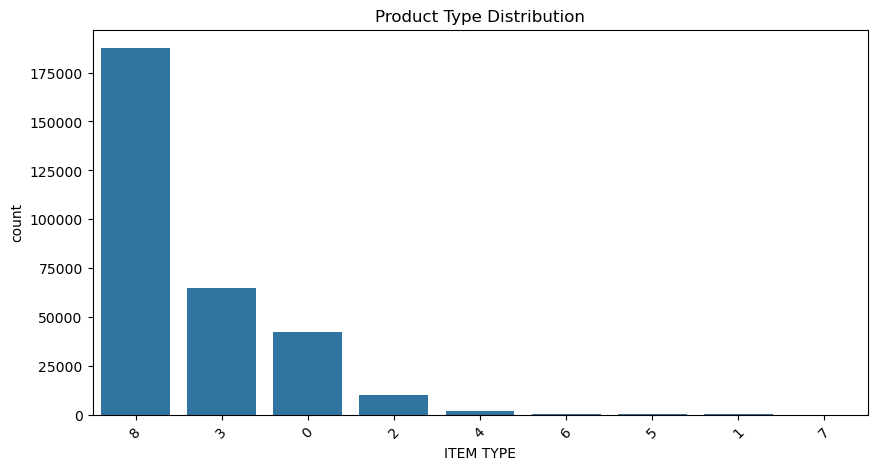

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="ITEM TYPE", order=df["ITEM TYPE"].value_counts().index)
plt.title("Product Type Distribution")
plt.xticks(rotation=45)
plt.show()

In [13]:
monthly_sales = df.groupby("MONTH")["RETAIL SALES"].sum()

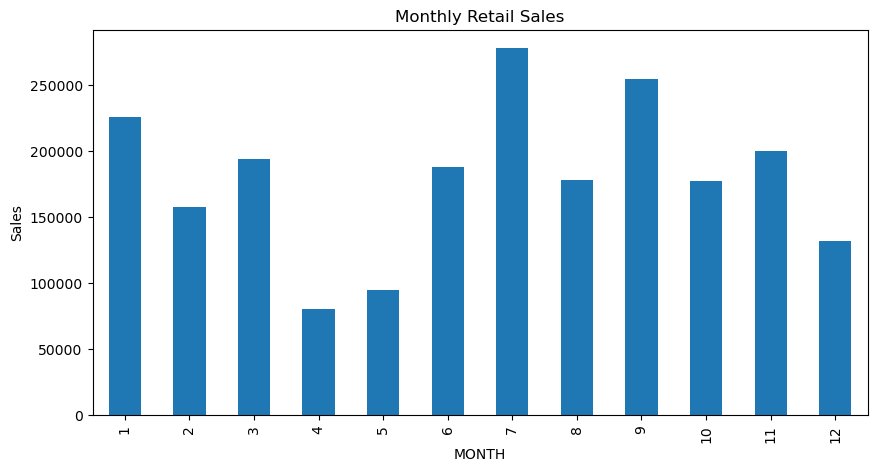

In [14]:
plt.figure(figsize=(10,5))
monthly_sales.plot(kind="bar")
plt.title("Monthly Retail Sales")
plt.ylabel("Sales")
plt.show()


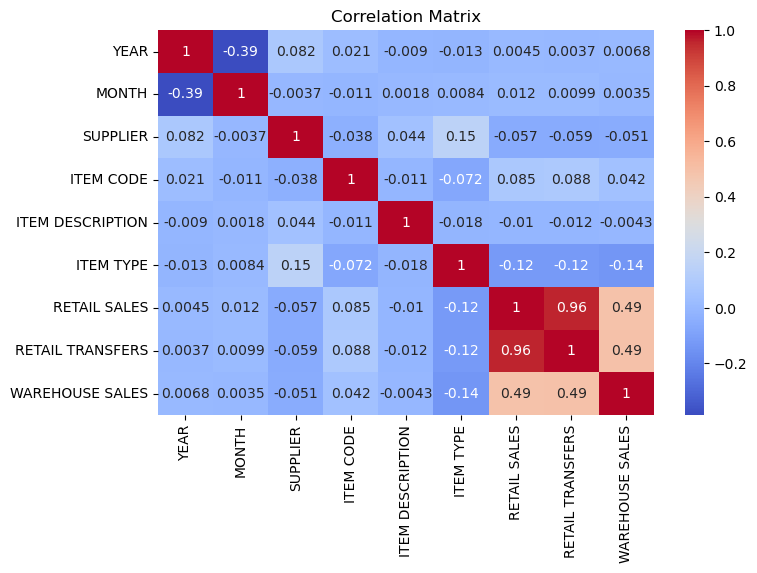

In [15]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [21]:
# ERROR FIX:
# ValueError: could not convert string to float: '50029A'
# Means some columns still contain text values.
# We must encode ALL object/string columns before training.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ======================
# TARGET COLUMN
# ======================
target = "RETAIL SALES"

X = df.drop(target, axis=1)
y = df[target]

# ======================
# TRAIN TEST SPLIT
# ======================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ======================
# MODEL
# ======================
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# ======================
# PREDICTION
# ======================
pred = model.predict(X_test)

# ======================
# RESULTS
# ======================
print("R2 Score :", r2_score(y_test, pred))
print("MAE      :", mean_absolute_error(y_test, pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, pred)))

# ======================
# FEATURE IMPORTANCE
# ======================
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance)

import joblib
joblib.dump(model, 'model.joblib', compress=3)

print("\nModel Saved Successfully!")

R2 Score : 0.9502462222093958
MAE      : 1.6005524467509131
RMSE     : 6.982930692982478
            Feature  Importance
6  RETAIL TRANSFERS    0.924566
4  ITEM DESCRIPTION    0.015851
1             MONTH    0.015822
3         ITEM CODE    0.015488
5         ITEM TYPE    0.008964
7   WAREHOUSE SALES    0.008147
0              YEAR    0.005719
2          SUPPLIER    0.005442

Model Saved Successfully!


In [17]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 3.3 MB/s  0:00:063.3 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 861.5/861.5 kB 4.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [gradio]5;237m━━━ 11/12 [gradio]


In [5]:
import joblib
import os

# Get the path to your model
# If it's in the same folder as this notebook, use 'model.pkl'
# Otherwise, use the full path you found earlier
input_file = 'model.pkl' 
output_file = 'model_compressed.pkl'

if os.path.exists(input_file):
    print(f"Found {input_file}. Starting compression...")
    model = joblib.load(input_file)
    # Compression level 3 is a good balance of speed and size
    joblib.dump(model, output_file, compress=3)
    
    # Check the new size
    old_size = os.path.getsize(input_file) / (1024 * 1024)
    new_size = os.path.getsize(output_file) / (1024 * 1024)
    print(f"Compression Done!")
    print(f"Old Size: {old_size:.2f} MB")
    print(f"New Size: {new_size:.2f} MB")
else:
    print(f"Error: Could not find {input_file} in {os.getcwd()}")

Error: Could not find model.pkl in /Users/ashishjadia/Warehouse_and_retail_sales


In [2]:
import joblib
import os

# Paste your copied path here
absolute_path = '/Users/ashishjadia/Warehouse_and_retail_sales/model.joblib' 

if os.path.exists(absolute_path):
    print("Found it! Compressing now...")
    model = joblib.load(absolute_path)
    
    # Save it to your CURRENT project folder so we can push it
    joblib.dump(model, 'model.pkl', compress=3) 
    print(f"Success! Compressed model saved to: {os.getcwd()}/model.pkl")
else:
    print("Still can't find it. Check the filename again!")

Found it! Compressing now...
Success! Compressed model saved to: /Users/ashishjadia/Warehouse_and_retail_sales/model.pkl
